In [20]:
# Define paths 
DATA_DIR = ROOT / "data"
CKPT_DIR = ROOT / "checkpoints"
OUTPUT_DIR = ROOT / "outputs"

for d in [DATA_DIR, CKPT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
# Set random seeds 
SEED = 1

import random
import numpy as np
import torch 

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Check CPU/GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current Device is {device}")


Current Device is cuda


In [33]:
import torch  
import torch.nn as nn  
import torch.optim as optim  
from torchvision import datasets, transforms  
from torch.utils.data import DataLoader  
import torch.nn.functional as F 
import numpy as np  
import matplotlib.pyplot as plt  
 
# Use GPU if available  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load MNIST dataset  
transform = transforms.ToTensor()  
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)  
train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True) 


In [34]:
# Build the encoder class
class Encoder(nn.Module): 
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20): 
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim) 
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
    def forward(self, x): 
        h = torch.relu(self.fc1(x)) 
        mu = self.fc_mu(h) 
        logvar = self.fc_logvar(h)
        return mu, logvar

In [35]:
# Build the decoder class 
class Decoder(nn.Module): 
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784): 
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, z):
        h = torch.relu(self.fc1(z)) 
        return torch.sigmoid(self.fc2(h))
        

In [36]:
# Build the VAE class 
class VAE(nn.Module): 
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20, output_dim=784):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, output_dim)
    
    def reparametrization(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std 
    
    def forward(self, x): 
        mu, logvar = self.encoder(x)
        z = self.reparametrization(mu, logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar

In [37]:
def loss_function(recon_x, x, mu, logvar): 
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_loss

Epoch 1, Loss: 164.7953
Epoch 2, Loss: 122.0494
Epoch 3, Loss: 114.8790
Epoch 4, Loss: 111.7152
Epoch 5, Loss: 109.9039
Epoch 6, Loss: 108.7032
Epoch 7, Loss: 107.8425
Epoch 8, Loss: 107.1551
Epoch 9, Loss: 106.6556
Epoch 10, Loss: 106.1929


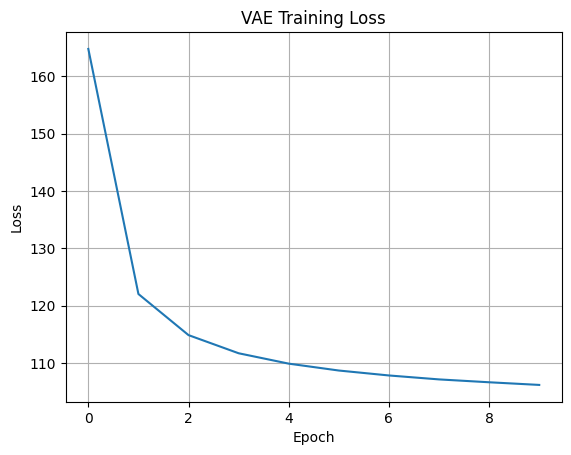

In [38]:
import matplotlib.pyplot as plt 

# Set training parameters 
epochs = 10  
learning_rate = 1e-3  

# Initialize model, optimizer 
model = VAE().to(device)  
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

# Track losses 
train_losses = [] 

# Training loop
model.train()  

for epoch in range(epochs):  
  total_loss = 0  
  for batch_idx, (x, _) in enumerate(train_loader):  
    x = x.view(-1, 784).to(device)  # Flatten images 
    optimizer.zero_grad() 

    recon_x, mu, logvar = model(x) 
    loss = loss_function(recon_x, x, mu, logvar) 
    loss.backward() 
    optimizer.step() 
     
    total_loss += loss.item() 
 
  avg_loss = total_loss / len(train_loader.dataset) 
  train_losses.append(avg_loss) 
  print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}") 

 

# Plotting the training loss 
plt.plot(train_losses) 
plt.title("VAE Training Loss") 
plt.xlabel("Epoch") 
plt.ylabel("Loss") 
plt.grid(True) 
plt.show() 


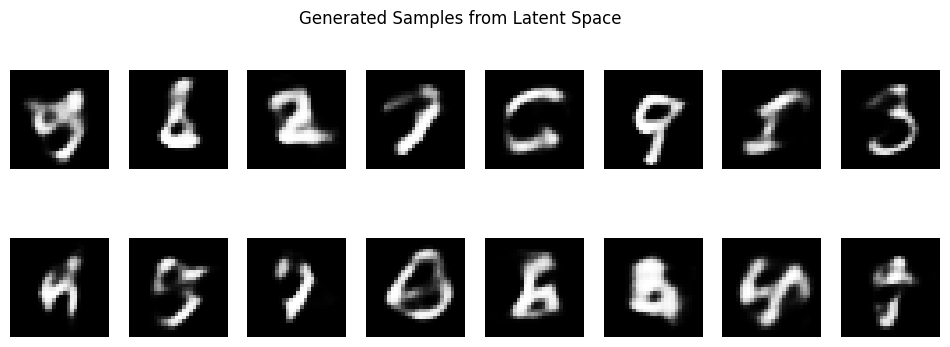

In [39]:
model.eval() 


# Generate random latent vectors 
with torch.no_grad(): 
  z = torch.randn(16, 20).to(device)  # 16 samples, 20-dimensional latent space 
  generated = model.decoder(z).cpu() 
  generated = generated.view(-1, 1, 28, 28) 

# Plot generated samples 
fig, axes = plt.subplots(2, 8, figsize=(12, 4)) 
for i, ax in enumerate(axes.flat): 
  ax.imshow(generated[i][0], cmap='gray') 
  ax.axis('off') 

plt.suptitle("Generated Samples from Latent Space") 
plt.show() 


In [41]:
def interpolate(model, z_start, z_end, steps=10):  
  vectors = torch.stack([  
    z_start * (1 - t) + z_end * t for t in torch.linspace(0, 1, steps)  
  ])  

  with torch.no_grad():  
    samples = model.decode(vectors.to(device)).cpu()  
  return samples.view(-1, 1, 28, 28)  

# Sample two random points  
z1 = torch.randn(1, 20)  
z2 = torch.randn(1, 20)  

# Interpolate and visualize  
interpolated_images = interpolate(model, z1, z2)  

# Plot results  
fig, axes = plt.subplots(1, 10, figsize=(15, 2))  
for i, ax in enumerate(axes.flat):  
  ax.imshow(interpolated_images[i][0], cmap='gray')  
  ax.axis('off')  

plt.suptitle("Latent Space Interpolation")  
plt.show() 


AttributeError: 'VAE' object has no attribute 'decode'